# Model Training

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

**Image Preprocessing Pipeline**

**Creating Transforms for Image Preprocessing**

Resizing and cropping images and then augmenting images dynamically for training the model followed by rescaling.

In [3]:
# --------------------------------------------------------------------------------
# Training Data - Resizing > Augmentation > Normalization
# --------------------------------------------------------------------------------
train_transform = keras.Sequential([
    layers.Resizing(96, 96),      # resizing image to 96x96
    layers.RandomRotation(0.03),  # randomly rotating by approx 10 degrees
    layers.RandomContrast(0.1),   # contrast +/- 10%
    layers.Rescaling(1./255),     # maps [0,255] to [-1,1]
], name="train_transform")

Only resizing and normalizing images for validation and test data.

In [4]:
# --------------------------------------------------------------------------------
# Valid and Test Data - Resizing > Normalization
# --------------------------------------------------------------------------------
valid_test_transform = keras.Sequential([
    layers.Resizing(96, 96),
    layers.Rescaling(1./255),
], name="valid_test_transform")

**Loading Dataset**

**Mounting Google Drive**

Mounting Google Drive for easier access everytime to the dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = '/content/drive/My Drive/dataset/split1_801010'

Mounted at /content/drive


**Loading images**

Loading images from subfolders of the dataset

In [6]:
import os

image_size = (96,96)
batch_size = 24

# training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'train'),
    labels='inferred',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)
# Apply training transforms (includes augmentation)
train_ds = train_ds.map(lambda x, y: (train_transform(x, training=True), y))

# validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'val'),
    labels='inferred',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    seed=42
)
# Apply standard transforms (no augmentation)
val_ds = val_ds.map(lambda x, y: (valid_test_transform(x, training=False), y))

# test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'test'),
    labels='inferred',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    seed=42
)
# Apply standard transforms (no augmentation)
test_ds = test_ds.map(lambda x, y: (valid_test_transform(x, training=False), y))

Found 480 files belonging to 6 classes.
Found 60 files belonging to 6 classes.
Found 60 files belonging to 6 classes.


## From Scratch CNN

### Model 1

**Creating and Training the CNN Model**

Creating a Convolutional Neural Network with **4 convolutional layers** of 32, 64, 128 and 256 fiters, **2 fully connected layers** of 128 and 64 neurons with dropout rates of 0.3 and 0.2 respectively and an **output layer** of 6 neurons with softmax activation function for classification.

In [ ]:
model = keras.Sequential([
    # Feature extractor
    layers.Input(shape=(96, 96, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # FULLY CONNECTED LAYER
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # OUTPUT LAYER
    layers.Dense(6, activation='softmax')
])

**Adding optimizer, loss and performance metric**

In [ ]:
# adding optimizer as Adam SGD (adaptive learning rate)
# loss = Categorical(6 classes),Crossentropy(penalty score),Sparse(int labels)
# accuracy is calculated
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_94 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,838 (6.02 MB)

 Trainable params: 1,576,838 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

**Training the model**

Now we fit the model to the training data.

In [ ]:
epochs = 100

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # check for valid_loss increase
    patience=10,   # 10 epochs to wait before stopping
    restore_best_weights=True   # revert to last best weights
)

'''
model.fit() returns history of train accuracy and loss,
valid accuracy and loss for each epoch
'''

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1,  # log progress bar and results per epoch
    callbacks=[early_stopping]
)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 227s 11s/step - accuracy: 0.1688 - loss: 1.7928 - val_accuracy: 0.1667 - val_loss: 1.7899
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 936ms/step - accuracy: 0.1625 - loss: 1.7936 - val_accuracy: 0.1667 - val_loss: 1.7871
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 796ms/step - accuracy: 0.2167 - loss: 1.7870 - val_accuracy: 0.1667 - val_loss: 1.7853
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 781ms/step - accuracy: 0.2062 - loss: 1.7887 - val_accuracy: 0.2333 - val_loss: 1.7812
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 771ms/step - accuracy: 0.1750 - loss: 1.7861 - val_accuracy: 0.3167 - val_loss: 1.7778
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 780ms/step - accuracy: 0.2292 - loss: 1.7808 - val_accuracy: 0.2833 - val_loss: 1.7719
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 769ms/step - accuracy: 0.2396 - loss: 1.7734 - val_accuracy: 0.2667 - val_loss: 1.7604
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 774ms/step - accuracy: 0.2458 - loss: 1.7734 - v

**Visualizing Training Progress**

Plotting the accuracy and loss curves to analyze the model's performance over time.

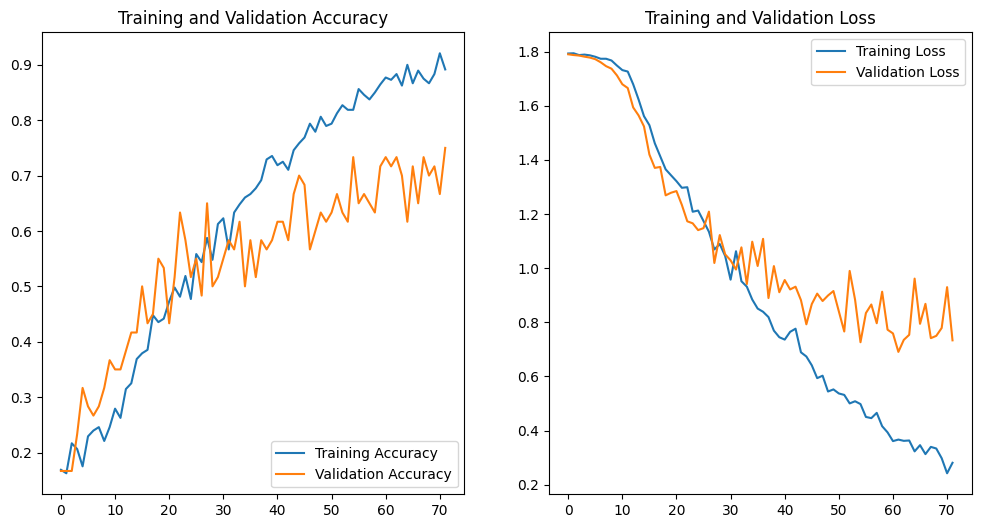

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history.history['accuracy']
valid_acc = history.history['val_accuracy']
train_loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving the Trained Model**

Saving the trained model to Google Drive for future inference.

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'cnn_from_scratch_model_1.keras')

# Save the model
model.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/cnn_from_scratch_model_1.keras


### Model 2

**Changing optimizer**

In [ ]:
from tensorflow.keras.optimizers import SGD

model.compile(
    optimizer=SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_662 (Conv2D)             │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_663 (Conv2D)             │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_664 (Conv2D)             │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_665 (Conv2D)             │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,838 (6.02 MB)

 Trainable params: 1,576,838 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

**Training the model on the same architecture**

In [ ]:
epochs = 100

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # check for valid_loss increase
    patience=10,   # 10 epochs to wait
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 781ms/step - accuracy: 0.2292 - loss: 1.7846 - val_accuracy: 0.2333 - val_loss: 1.7450
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 786ms/step - accuracy: 0.2792 - loss: 1.7679 - val_accuracy: 0.2833 - val_loss: 1.7564
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 756ms/step - accuracy: 0.2146 - loss: 1.7648 - val_accuracy: 0.3333 - val_loss: 1.7181
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 756ms/step - accuracy: 0.2646 - loss: 1.7314 - val_accuracy: 0.3333 - val_loss: 1.6936
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 771ms/step - accuracy: 0.2062 - loss: 1.7852 - val_accuracy: 0.1833 - val_loss: 1.7742
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 751ms/step - accuracy: 0.2708 - loss: 1.7417 - val_accuracy: 0.3167 - val_loss: 1.6600
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 745ms/step - accuracy: 0.2812 - loss: 1.7186 - val_accuracy: 0.3167 - val_loss: 1.6351
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 737ms/step - accuracy: 0.2937 - loss: 1.7248 - 

**Visualizing Training Progress**

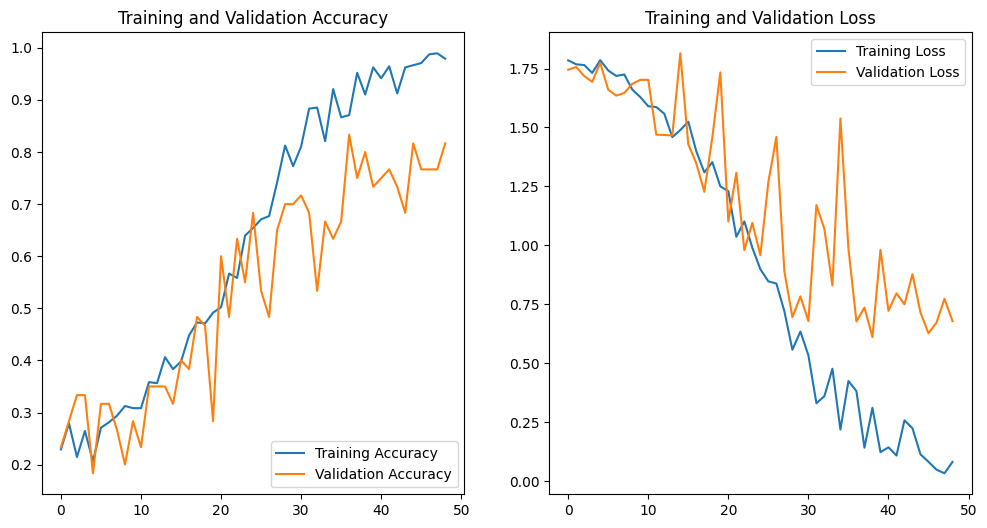

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history.history['accuracy']
valid_acc = history.history['val_accuracy']
train_loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving the Trained Model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'cnn_from_scratch_model_2.keras')

# Save the model
model.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/cnn_from_scratch_model_2.keras


### Model 3

**Changing optimizer and learning rate**

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_94 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,838 (6.02 MB)

 Trainable params: 1,576,838 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

**Training the model**

In [ ]:
epochs = 100

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # check for valid_loss increase
    patience=10,   # 10 epochs to wait
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 787ms/step - accuracy: 0.2708 - loss: 1.6452 - val_accuracy: 0.2667 - val_loss: 1.6517
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 776ms/step - accuracy: 0.2937 - loss: 1.5945 - val_accuracy: 0.2333 - val_loss: 1.6644
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 771ms/step - accuracy: 0.3021 - loss: 1.5801 - val_accuracy: 0.1667 - val_loss: 1.6432
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 764ms/step - accuracy: 0.3042 - loss: 1.5602 - val_accuracy: 0.2667 - val_loss: 1.6500
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 770ms/step - accuracy: 0.3167 - loss: 1.5695 - val_accuracy: 0.2667 - val_loss: 1.6269
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 767ms/step - accuracy: 0.3000 - loss: 1.5573 - val_accuracy: 0.2833 - val_loss: 1.6157
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 789ms/step - accuracy: 0.3104 - loss: 1.5536 - val_accuracy: 0.2833 - val_loss: 1.6077
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 792ms/step - accuracy: 0.3208 - loss: 1.5332 - 

**Visualizing Training Progress**

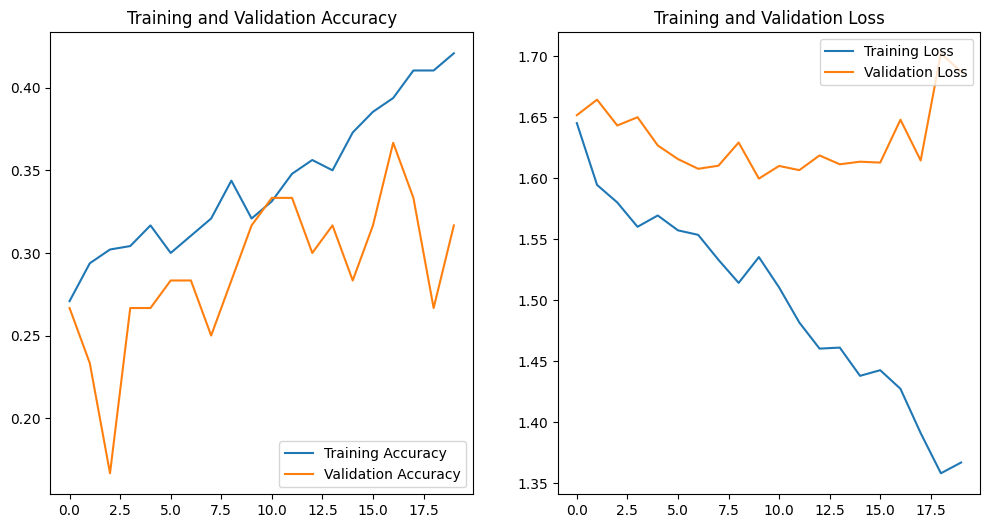

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valaaid accuracy and loss from history
train_acc = history.history['accuracy']
valid_acc = history.history['val_accuracy']
train_loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving Model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'cnn_from_scratch_model_3.keras')

# Save the model
model.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/cnn_from_scratch_model_3.keras


## Transfer Learning - 1

### Model 1

**Using MobileNetV2 architecture**

As dataset is small, therefore instead o complex architectures, MobileNetV2 is used that has a total of 154 layers including convolutional layers with Batch Normalization and ReLU activation function. A summary of this network is as follows:

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

**As a Feature Extractor**

Keeping the pre-trained network as it is and using it as a Feature Extractor, adding custom Classifier and an output layer in the model.

In [ ]:
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

# Freeze pretrained layers
base_model.trainable = False

# Build Transfer Learning Model
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),
    Dropout(0.3),

    # fully connected layer (classifier)
    Dense(128, activation='relu'),
    Dropout(0.3),

    # output layer
    Dense(6, activation='softmax')
])


# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Training the model with early stopping**

In [ ]:
epochs = 100

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,   # 10 epochs to wait
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 634ms/step - accuracy: 0.2708 - loss: 2.1359 - val_accuracy: 0.4333 - val_loss: 1.3352
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step - accuracy: 0.4875 - loss: 1.3187 - val_accuracy: 0.5167 - val_loss: 1.1008
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 564ms/step - accuracy: 0.5729 - loss: 1.0923 - val_accuracy: 0.6333 - val_loss: 0.9698
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 557ms/step - accuracy: 0.6271 - loss: 0.9307 - val_accuracy: 0.6667 - val_loss: 0.9098
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step - accuracy: 0.6521 - loss: 0.8915 - val_accuracy: 0.6500 - val_loss: 0.8478
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 559ms/step - accuracy: 0.6958 - loss: 0.7370 - val_accuracy: 0.6333 - val_loss: 0.8048
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 481ms/step - accuracy: 0.7688 - loss: 0.6390 - val_accuracy: 0.7000 - val_loss: 0.7947
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 497ms/step - accuracy: 0.7854 - loss: 0.5755 - 

**Visualizing training**

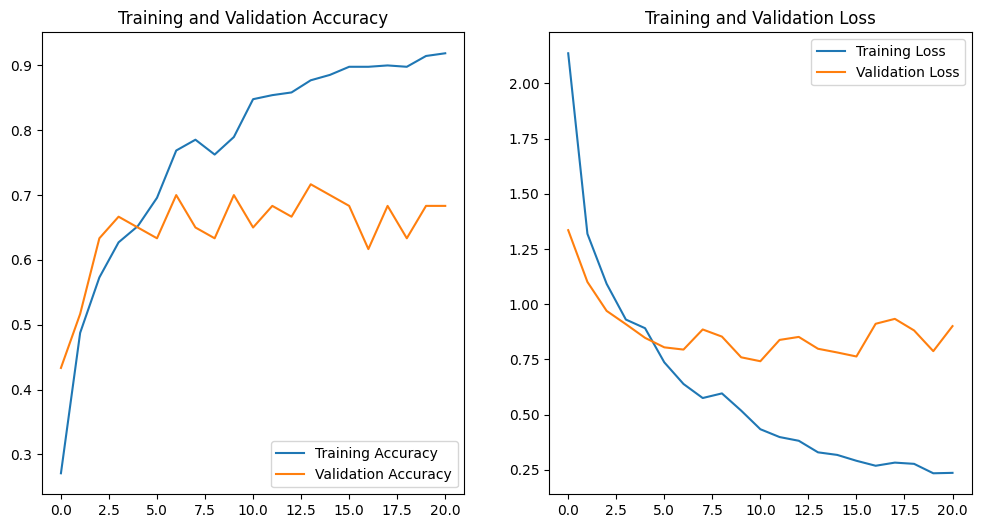

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history.history['accuracy']
valid_acc = history.history['val_accuracy']
train_loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving trained model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'mobilenetv2_1.keras')

# Save the model
model.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/mobilenetv2_1.keras


### Model 2

**Fine-Tuning**

In [ ]:
from tensorflow.keras import layers, models

# Base model (already loaded)
base_model.trainable = False  # freeze first

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    # Improved classifier
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(6, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Fine-tuning the model**

Freezing the first 70% of Feature Extractor (MobileNetV2) and retraining the remaining layers on our dataset.

In [ ]:
base_model.trainable = True

# freeze first 70%
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False   # freeze

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True    # retrain

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

**Initial training on 25 epochs**

In [ ]:
initial_epochs = 25

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 685ms/step - accuracy: 0.1667 - loss: 2.7225 - val_accuracy: 0.2667 - val_loss: 1.7735 - learning_rate: 1.0000e-05
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 612ms/step - accuracy: 0.1833 - loss: 2.6280 - val_accuracy: 0.2000 - val_loss: 1.7759 - learning_rate: 1.0000e-05
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 622ms/step - accuracy: 0.1562 - loss: 2.6998 - val_accuracy: 0.2167 - val_loss: 1.7804 - learning_rate: 1.0000e-05
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.1980 - loss: 2.6418
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 628ms/step - accuracy: 0.1729 - loss: 2.6169 - val_accuracy: 0.2500 - val_loss: 1.7837 - learning_rate: 1.0000e-05
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 607ms/step - accuracy: 0.1937 - loss: 2.4577 - val_accuracy: 0.2833 - val_loss: 1.7910 - learning_rate: 2.0000e-06
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 624ms/step - accuracy

**Training again for 25 and 50 epochs**

Using lower learning rate now for training and "reduce_lr" reduces the learning rate when model starts to overfit.

In [ ]:
# Unfreeze base model
base_model.trainable = True

# Freeze first 70%
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Recompile with very low LR
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 25

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 656ms/step - accuracy: 0.1771 - loss: 2.7547 - val_accuracy: 0.2333 - val_loss: 1.7747 - learning_rate: 1.0000e-05
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 624ms/step - accuracy: 0.1771 - loss: 2.5897 - val_accuracy: 0.2333 - val_loss: 1.7849 - learning_rate: 1.0000e-05
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.1659 - loss: 2.5825
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 615ms/step - accuracy: 0.1604 - loss: 2.6149 - val_accuracy: 0.2333 - val_loss: 1.7932 - learning_rate: 1.0000e-05
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 615ms/step - accuracy: 0.1792 - loss: 2.5994 - val_accuracy: 0.2833 - val_loss: 1.8024 - learning_rate: 2.0000e-06
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 610ms/step - accuracy: 0.1937 - loss: 2.5913 - val_accuracy: 0.2833 - val_loss: 1.8149 - learning_rate: 2.0000e-06
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy:

In [ ]:
extra_epochs = 50

history_fine_extra = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=extra_epochs,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 625ms/step - accuracy: 0.1729 - loss: 2.6462 - val_accuracy: 0.2167 - val_loss: 1.7893 - learning_rate: 4.0000e-07
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 598ms/step - accuracy: 0.1667 - loss: 2.7863 - val_accuracy: 0.2167 - val_loss: 1.8019 - learning_rate: 4.0000e-07
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.1518 - loss: 2.7433
Epoch 3: ReduceLROnPlateau reducing learning rate to 1e-07.
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 609ms/step - accuracy: 0.1729 - loss: 2.6903 - val_accuracy: 0.2500 - val_loss: 1.8182 - learning_rate: 4.0000e-07
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 613ms/step - accuracy: 0.1521 - loss: 2.6471 - val_accuracy: 0.2833 - val_loss: 1.8293 - learning_rate: 1.0000e-07
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 617ms/step - accuracy: 0.1813 - loss: 2.5890 - val_accuracy: 0.2833 - val_loss: 1.8416 - learning_rate: 1.0000e-07
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 617ms/step - accuracy: 0.1625 - loss: 

**Visualizing training and validation curves**

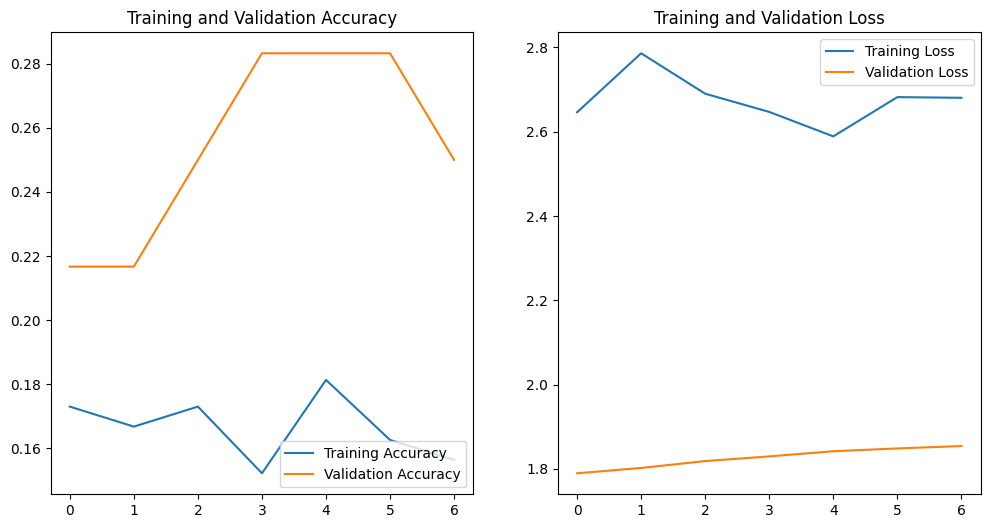

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history_fine_extra.history['accuracy']
valid_acc = history_fine_extra.history['val_accuracy']
train_loss = history_fine_extra.history['loss']
valid_loss = history_fine_extra.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving the model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'mobilenetv2_2.keras')

# Save the model
model.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/mobilenetv2_2.keras


### Model 3

**Fine-tuning**

Retraining the last 30 layers of pre-trained model

**Initial training for 20 epochs**

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Unfreeze base model
base_model.trainable = True

# Freeze first layers, unfreeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False   #freeze

# Recompile model with very low learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning
fine_tune_epochs = 20

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 621ms/step - accuracy: 0.1917 - loss: 2.6605 - val_accuracy: 0.2333 - val_loss: 1.7979
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 545ms/step - accuracy: 0.1854 - loss: 2.5378 - val_accuracy: 0.2833 - val_loss: 1.7999
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 591ms/step - accuracy: 0.1896 - loss: 2.5951 - val_accuracy: 0.2833 - val_loss: 1.8030
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 585ms/step - accuracy: 0.1688 - loss: 2.5544 - val_accuracy: 0.2833 - val_loss: 1.8021
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 578ms/step - accuracy: 0.1875 - loss: 2.5500 - val_accuracy: 0.2833 - val_loss: 1.7984
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 610ms/step - accuracy: 0.2146 - loss: 2.3724 - val_accuracy: 0.2833 - val_loss: 1.7967
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 599ms/step - accuracy: 0.1937 - loss: 2.4423 - val_accuracy: 0.2833 - val_loss: 1.7893
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 551ms/step - accuracy: 0.2125 - loss: 2.4873 - val_accu

**Visualizing training**

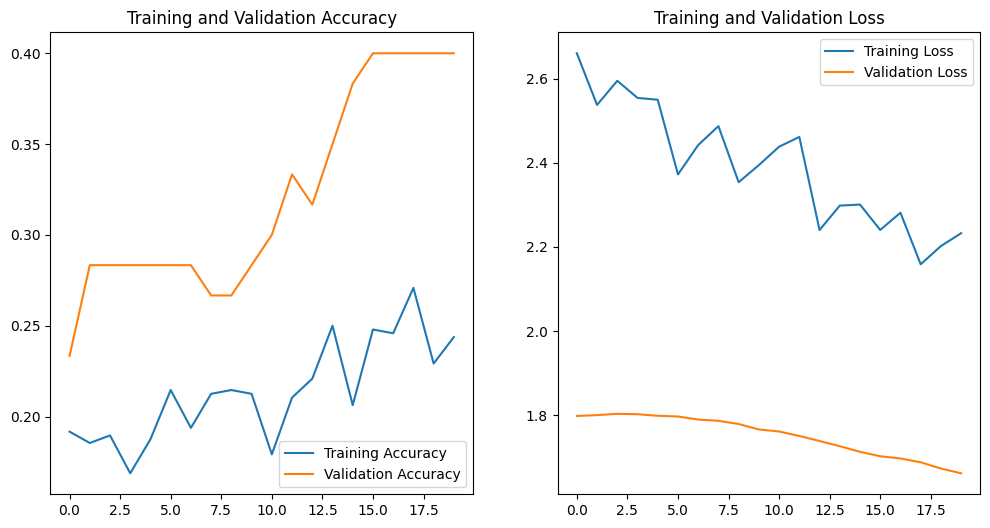

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valaaid accuracy and loss from history
train_acc = history_fine.history['accuracy']
valid_acc = history_fine.history['val_accuracy']
train_loss = history_fine.history['loss']
valid_loss = history_fine.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Training again for 100 epochs**

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Unfreeze base model
base_model.trainable = True

# Freeze first layers, unfreeze last layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile model with very low learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning
fine_tune_epochs = 100

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 636ms/step - accuracy: 0.2917 - loss: 2.1276 - val_accuracy: 0.3833 - val_loss: 1.6511
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 529ms/step - accuracy: 0.2604 - loss: 2.1489 - val_accuracy: 0.3833 - val_loss: 1.6372
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 572ms/step - accuracy: 0.3000 - loss: 2.1083 - val_accuracy: 0.4000 - val_loss: 1.6226
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 614ms/step - accuracy: 0.2625 - loss: 2.1367 - val_accuracy: 0.3500 - val_loss: 1.6157
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 596ms/step - accuracy: 0.2917 - loss: 2.0185 - val_accuracy: 0.3833 - val_loss: 1.5975
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 594ms/step - accuracy: 0.2979 - loss: 2.0447 - val_accuracy: 0.3833 - val_loss: 1.5832
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 594ms/step - accuracy: 0.2562 - loss: 2.0043 - val_accuracy: 0.3667 - val_loss: 1.5652
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 603ms/step - accuracy: 0.2833 - loss: 2.0388 - 

**Visualizing training**

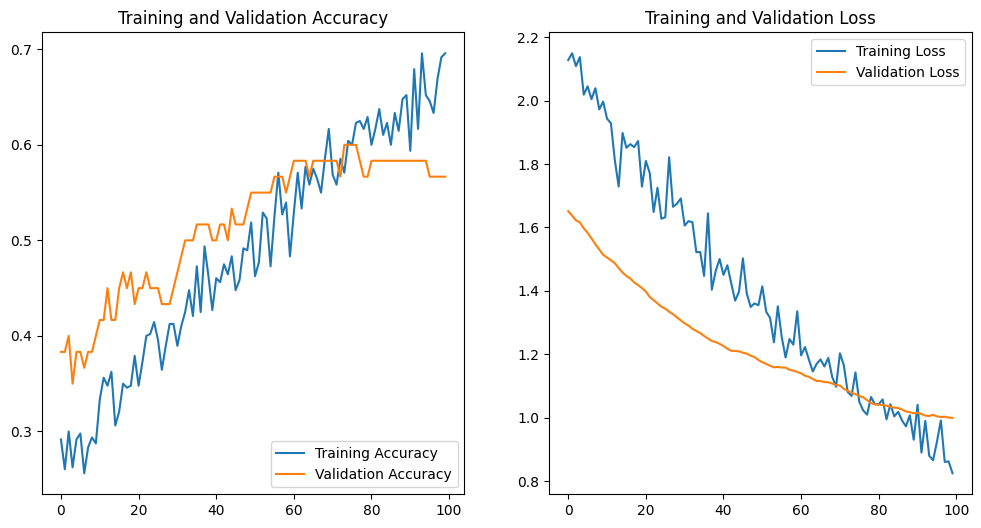

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history_fine.history['accuracy']
valid_acc = history_fine.history['val_accuracy']
train_loss = history_fine.history['loss']
valid_loss = history_fine.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving the model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'mobilenetv2_3.keras')

# Save the model
model.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/mobilenetv2_3.keras


## Transfer Learning - 2

**Using InceptionV3 architecture**

### Model 1

**As A Feature Extractor**

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# loading pre-trained model
base_model_1 = InceptionV3(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Freeze Feature Extractor
base_model_1.trainable = False

# adding classifier
model1 = Sequential([
    base_model_1,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

# early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# compile and train
model1.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history1 = model1.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stopping])

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 844ms/step - accuracy: 0.2271 - loss: 1.9971 - val_accuracy: 0.2833 - val_loss: 1.6571
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 718ms/step - accuracy: 0.3896 - loss: 1.5133 - val_accuracy: 0.4000 - val_loss: 1.4990
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 691ms/step - accuracy: 0.4938 - loss: 1.3485 - val_accuracy: 0.4833 - val_loss: 1.3164
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 742ms/step - accuracy: 0.5083 - loss: 1.2396 - val_accuracy: 0.4667 - val_loss: 1.3524
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 722ms/step - accuracy: 0.5417 - loss: 1.1241 - val_accuracy: 0.4833 - val_loss: 1.2738
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 707ms/step - accuracy: 0.5896 - loss: 1.0229 - val_accuracy: 0.4833 - val_loss: 1.2768
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 642ms/step - accuracy: 0.6396 - loss: 0.9124 - val_accuracy: 0.5167 - val_loss: 1.2580
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 706ms/step - accuracy: 0.7125 - loss: 0.7549 - val_accu

**Visualizing training**

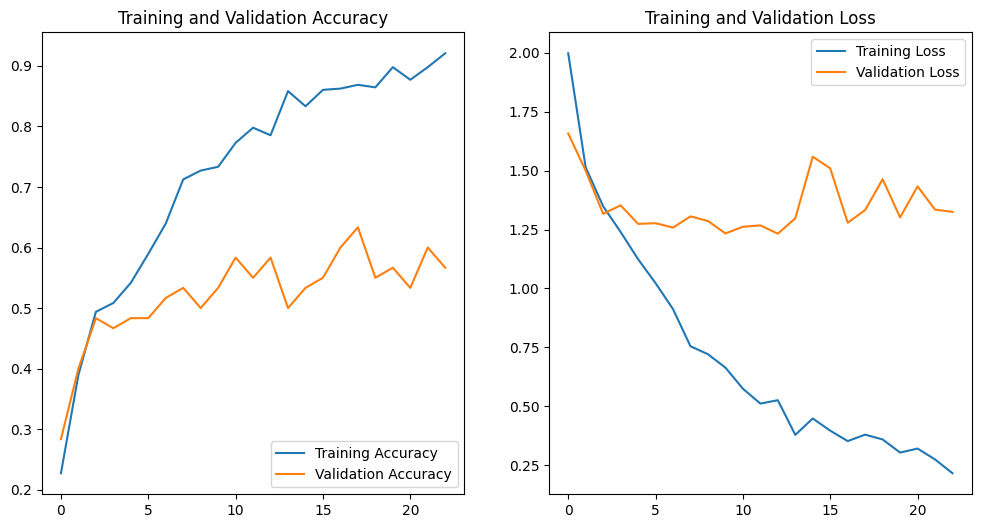

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history1.history['accuracy']
valid_acc = history1.history['val_accuracy']
train_loss = history1.history['loss']
valid_loss = history1.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving the model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'inceptionv3_1.keras')

# Save the model
model1.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/inceptionv3_1.keras


### Model 2

**Fine-tuning**

In [ ]:
from tensorflow.keras.applications import InceptionV3

# pre-trained model
base_model_2 = InceptionV3(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Fine-Tuning - freeze top 15 layers
for layer in base_model_2.layers[:15]:
    layer.trainable = False
for layer in base_model_2.layers[15:]:
    layer.trainable = True

# adding classifier
model2 = Sequential([
    base_model_2,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

# Use lower learning rate for fine-tuning
model2.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stopping])

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2125 - loss: 1.8813 - val_accuracy: 0.2500 - val_loss: 2.0666
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3438 - loss: 1.6685 - val_accuracy: 0.2833 - val_loss: 1.7556
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4292 - loss: 1.5303 - val_accuracy: 0.3667 - val_loss: 1.5666
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5292 - loss: 1.3116 - val_accuracy: 0.4833 - val_loss: 1.4201
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6146 - loss: 1.1232 - val_accuracy: 0.5500 - val_loss: 1.2882
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6604 - loss: 0.9519 - val_accuracy: 0.5500 - val_loss: 1.1796
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7792 - loss: 0.7008 - val_accuracy: 0.5833 - val_loss: 1.0545
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8188 - loss: 0.5621 - val_accuracy: 0.6667 - val_loss:

**Visualizing training**

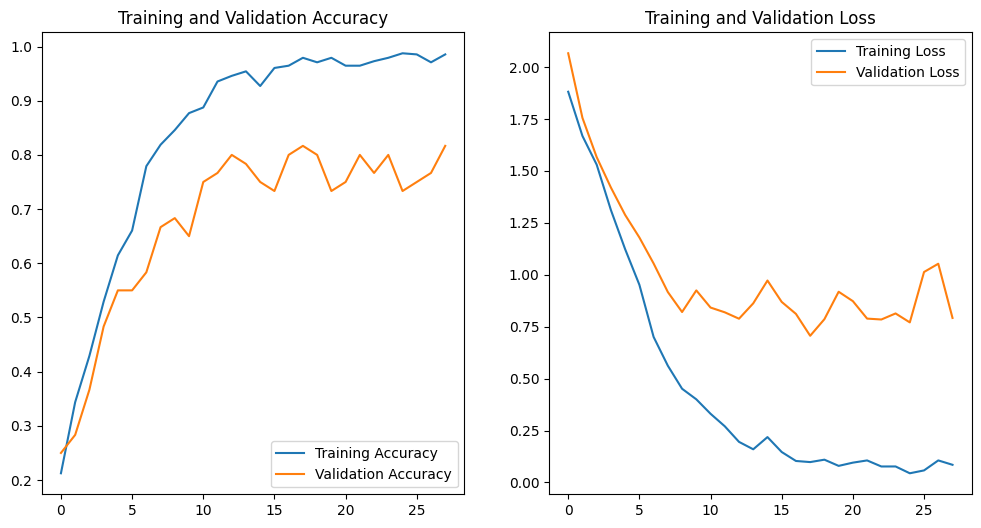

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history2.history['accuracy']
valid_acc = history2.history['val_accuracy']
train_loss = history2.history['loss']
valid_loss = history2.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'inceptionv3_2.keras')

# Save the model
model2.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/inceptionv3_2.keras


### Model 3

**Fine-tuning**

In [ ]:
from tensorflow.keras.applications import InceptionV3

# pre-trained Model
base_model_3 = InceptionV3(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# fine-tuning: deep retraining
base_model_3.trainable = True
for layer in base_model_3.layers[:20]: # freezing the first 20 layers
    layer.trainable = False

# adding classifier
model3 = Sequential([
    base_model_3,
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.2),

    Dense(6, activation='softmax')
])

# Use very low learning rate for deep fine-tuning
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history3 = model3.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stopping])

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.2188 - loss: 1.8625 - val_accuracy: 0.3167 - val_loss: 1.8458
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3167 - loss: 1.6896 - val_accuracy: 0.3500 - val_loss: 1.5797
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4500 - loss: 1.4572 - val_accuracy: 0.4667 - val_loss: 1.3989
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5917 - loss: 1.1773 - val_accuracy: 0.5167 - val_loss: 1.2110
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6896 - loss: 0.9597 - val_accuracy: 0.5667 - val_loss: 1.0480
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7583 - loss: 0.7669 - val_accuracy: 0.6000 - val_loss: 0.9282
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8375 - loss: 0.5635 - val_accuracy: 0.6833 - val_loss: 0.8446
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8771 - loss: 0.4775 - val_accuracy: 0.7000 - val_loss:

**Visualizing training**

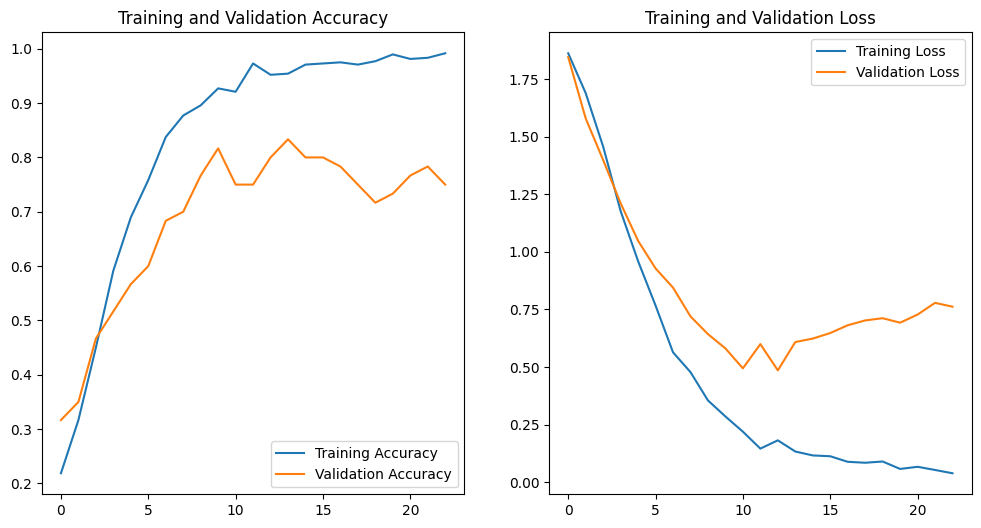

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history3.history['accuracy']
valid_acc = history3.history['val_accuracy']
train_loss = history3.history['loss']
valid_loss = history3.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Saving the model**

In [ ]:
# Define the save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'inceptionv3_3.keras')

# Save the model
model3.save(save_path)
print(f'Model saved successfully at: {save_path}')

Model saved successfully at: /content/drive/My Drive/models/inceptionv3_3.keras


# Model Selection

## Selecting top 3 models

### From Scratch CNN

**Model 1**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/cnn_from_scratch_model_1.keras")

loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.7167 - loss: 0.6907
Validation Loss: 0.690721
Validation Accuracy: 0.716667


In [ ]:
from sklearn.metrics import confusion_matrix

# Get true labels from val_ds
y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())

# Get predictions from the model
y_pred_probabilities = model.predict(val_ds)
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step


array([[7, 1, 2, 0, 0, 0],
       [0, 8, 2, 0, 0, 0],
       [0, 2, 7, 1, 0, 0],
       [0, 1, 0, 9, 0, 0],
       [0, 1, 3, 0, 4, 2],
       [0, 0, 1, 0, 1, 8]])

**Model 2**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/cnn_from_scratch_model_2.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.8000 - loss: 0.6109
Validation Loss: 0.610925
Validation Accuracy: 0.800000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step


array([[ 6,  0,  2,  1,  1,  0],
       [ 0, 10,  0,  0,  0,  0],
       [ 0,  3,  7,  0,  0,  0],
       [ 0,  0,  0, 10,  0,  0],
       [ 0,  0,  0,  0,  9,  1],
       [ 0,  0,  1,  1,  2,  6]])

**Model 3**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/cnn_from_scratch_model_3.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.3167 - loss: 1.5997
Validation Loss: 1.599707
Validation Accuracy: 0.316667
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step


array([[ 2,  4,  1,  3,  0,  0],
       [ 0, 10,  0,  0,  0,  0],
       [ 0,  4,  2,  2,  0,  2],
       [ 0,  4,  1,  4,  1,  0],
       [ 0,  6,  1,  1,  0,  2],
       [ 0,  7,  1,  0,  1,  1]])

**Best Pick**

Model 2 is picked (Accuracy: 0.80, Loss: 0.61)

### Transfer Learning - 1

**Model 1**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/mobilenetv2_1.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.6500 - loss: 0.7420
Validation Loss: 0.742004
Validation Accuracy: 0.650000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 462ms/step


array([[5, 2, 3, 0, 0, 0],
       [1, 7, 2, 0, 0, 0],
       [0, 1, 6, 2, 1, 0],
       [0, 0, 0, 6, 3, 1],
       [0, 0, 1, 0, 8, 1],
       [0, 0, 0, 1, 2, 7]])

**Model 2**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/mobilenetv2_2.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.2167 - loss: 1.7893
Validation Loss: 1.789270
Validation Accuracy: 0.216667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 487ms/step


array([[4, 1, 1, 0, 1, 3],
       [2, 3, 0, 2, 0, 3],
       [4, 2, 1, 1, 1, 1],
       [3, 2, 0, 1, 0, 4],
       [4, 0, 0, 0, 0, 6],
       [3, 1, 1, 0, 1, 4]])

**Model 3**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/mobilenetv2_3.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.5667 - loss: 0.9999
Validation Loss: 0.999872
Validation Accuracy: 0.566667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 483ms/step


array([[5, 4, 0, 1, 0, 0],
       [2, 8, 0, 0, 0, 0],
       [1, 3, 4, 1, 0, 1],
       [0, 1, 0, 5, 4, 0],
       [0, 0, 1, 2, 4, 3],
       [0, 0, 0, 1, 1, 8]])

**Best Pick**

Model 1 is picked (Accuracy: 0.65, Loss: 0.74)

### Transfer Learning - 2

**Model 1**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/inceptionv3_1.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step - accuracy: 0.5833 - loss: 1.2323
Validation Loss: 1.232250
Validation Accuracy: 0.583333
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step


array([[6, 2, 0, 0, 2, 0],
       [2, 5, 1, 1, 1, 0],
       [1, 2, 5, 1, 1, 0],
       [0, 1, 0, 6, 3, 0],
       [0, 0, 0, 2, 6, 2],
       [0, 0, 0, 1, 2, 7]])

**Model 2**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/inceptionv3_2.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 328ms/step - accuracy: 0.8167 - loss: 0.7062
Validation Loss: 0.706200
Validation Accuracy: 0.816667
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 925ms/step


array([[ 6,  2,  2,  0,  0,  0],
       [ 0,  7,  1,  1,  1,  0],
       [ 0,  1,  9,  0,  0,  0],
       [ 0,  0,  0,  7,  2,  1],
       [ 0,  0,  0,  0, 10,  0],
       [ 0,  0,  0,  0,  0, 10]])

**Model 3**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/inceptionv3_3.keras")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.6f}")
print(f"Validation Accuracy: {accuracy:.6f}")

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_pred_probabilities = model.predict(val_ds)  # predict on valid data
y_pred = np.argmax(y_pred_probabilities, axis=1)  # get label of max prob
cm = confusion_matrix(y_true, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 296ms/step - accuracy: 0.8000 - loss: 0.4851
Validation Loss: 0.485135
Validation Accuracy: 0.800000
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 940ms/step


array([[ 7,  2,  1,  0,  0,  0],
       [ 1,  8,  1,  0,  0,  0],
       [ 0,  1,  8,  0,  1,  0],
       [ 0,  1,  0,  8,  1,  0],
       [ 0,  0,  2,  1,  7,  0],
       [ 0,  0,  0,  0,  0, 10]])

**Best Pick**

Model 3 is picked (Accuracy: 0.80, Loss: 0.48)

=> Loss is significantly lower than Model 2 indicating better generalization.

## Selecting best model

### Further Training on Validation Set

Training the 3 picked models on the validation dataset with low learning rate and few epochs to avoid overfitting on small valid set (technically fine-tuning).

**Picked Model 1 (CNN Model 2)**

In [ ]:
from tensorflow.keras.models import load_model
import os

# loading and training the model
path = '/content/drive/My Drive/models/cnn_from_scratch_model_2.keras'
picked_1 = load_model(path)

# re-compile with low LR
picked_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# training on validation dataset
print("Training further on validation dataset...")
picked_1.fit(val_ds, epochs=5, verbose=1)

# saving the fine-tuned model
save_path = '/content/drive/My Drive/models/cnn_from_scratch_model_2_finetuned.keras'
picked_1.save(save_path)
print(f'Model saved at: {save_path}')

Training further on validation dataset...
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.7500 - loss: 0.7892
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7833 - loss: 0.5194
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 566ms/step - accuracy: 0.7667 - loss: 0.6407
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 553ms/step - accuracy: 0.7333 - loss: 0.7345
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 823ms/step - accuracy: 0.8167 - loss: 0.6284
Model saved at: /content/drive/My Drive/models/cnn_from_scratch_model_2_finetuned.keras


**Picked Model 2 (MobileNetV2 Model 1)**

In [ ]:
from tensorflow.keras.models import load_model
import os

# loading and training the model
path = '/content/drive/My Drive/models/mobilenetv2_1.keras'
picked_2 = load_model(path)

# re-compile with low LR
picked_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# training on validation dataset
print("Training further on validation dataset...")
picked_2.fit(val_ds, epochs=5, verbose=1)

# save the fine-tuned model
save_path = '/content/drive/My Drive/models/mobilenetv2_1_finetuned.keras'
picked_2.save(save_path)
print(f'Model saved at: {save_path}')

Training further on validation dataset...
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 461ms/step - accuracy: 0.6500 - loss: 1.0100
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 541ms/step - accuracy: 0.6000 - loss: 1.0124
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 499ms/step - accuracy: 0.6333 - loss: 0.8932
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 853ms/step - accuracy: 0.6167 - loss: 0.8179
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 464ms/step - accuracy: 0.5667 - loss: 0.9440
Model saved at: /content/drive/My Drive/models/mobilenetv2_1_finetuned.keras


**Picked Model 3 (InceptionV3 Model 3)**

In [ ]:
from tensorflow.keras.models import load_model
import os

# loading and training the model
path = '/content/drive/My Drive/models/inceptionv3_3.keras'
picked_3 = load_model(path)

# re-compile with low LR
picked_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# training on validation dataset
print("Training further on validation dataset...")
picked_3.fit(val_ds, epochs=5, verbose=1)

# save the fine-tuned model
save_path = '/content/drive/My Drive/models/inceptionv3_3_finetuned.keras'
picked_3.save(save_path)
print(f'Model saved at: {save_path}')

Training further on validation dataset...
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.3000 - loss: 2.4526
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3833 - loss: 2.0557
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3500 - loss: 1.9877
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4167 - loss: 1.8136
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4167 - loss: 1.6858
Model saved at: /content/drive/My Drive/models/inceptionv3_3_finetuned.keras


### Final Testing

Now evaluating on the test set to pick the best model among all.

**Picked Model 1**

In [ ]:
from tensorflow.keras.models import load_model
import os

path = '/content/drive/My Drive/models/cnn_from_scratch_model_2_finetuned.keras'
picked_1 = load_model(path)
test_loss, test_acc = picked_1.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.7000 - loss: 0.8437
Test Accuracy: 0.7000
Test Loss: 0.8437


**Picked Model 2**

In [ ]:
from tensorflow.keras.models import load_model
import os

path = '/content/drive/My Drive/models/mobilenetv2_1_finetuned.keras'
picked_2 = load_model(path)
test_loss, test_acc = picked_2.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 715ms/step - accuracy: 0.6667 - loss: 0.8337
Test Accuracy: 0.6667
Test Loss: 0.8337


**Picked Model 3**

In [ ]:
from tensorflow.keras.models import load_model
import os
import numpy as np

path = '/content/drive/My Drive/models/inceptionv3_3_finetuned.keras'
picked_3 = load_model(path)
test_loss, test_acc = picked_3.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8167 - loss: 0.6376
Test Accuracy: 0.8167
Test Loss: 0.6376


**Final Pick**



InceptionV3 Model 3 (Finetuned) is picked as the best model with a Test Accuracy of 81.67% and a Test Loss of 63.76%.

# Changing Data Split Ratio

Using another data split ratio of 70-15-15 (train-valid-test) on the final selected model i.e. InceptionV3 Model 3.

## Split 2 (70-15-15)

**Loading new split**

In [ ]:
dataset_path = '/content/drive/My Drive/dataset/split2_701515'
import os

image_size = (96,96)
batch_size = 24

# training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'train'),
    labels='inferred',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)
# Apply training transforms (includes augmentation)
train_ds = train_ds.map(lambda x, y: (train_transform(x, training=True), y))

# validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'val'),
    labels='inferred',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    seed=42
)
# Apply standard transforms (no augmentation)
val_ds = val_ds.map(lambda x, y: (valid_test_transform(x, training=False), y))

# test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'test'),
    labels='inferred',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    seed=42
)
# Apply standard transforms (no augmentation)
test_ds = test_ds.map(lambda x, y: (valid_test_transform(x, training=False), y))

Found 420 files belonging to 6 classes.
Found 90 files belonging to 6 classes.
Found 90 files belonging to 6 classes.


**Training on Train Set**

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

epochs = 100

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # check for valid_loss increase
    patience=10,   # 10 epochs to wait before stopping
    restore_best_weights=True   # revert to last best weights
)

# pre-trained Model
base_model_3 = InceptionV3(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# fine-tuning: deep retraining
base_model_3.trainable = True
for layer in base_model_3.layers[:20]:
    layer.trainable = False

# adding classifier
model3 = Sequential([
    base_model_3,
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.2),

    Dense(6, activation='softmax')
])

# very low learning rate for deep fine-tuning
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history3 = model3.fit(train_ds, validation_data=val_ds, epochs=50, verbose=1, callbacks=[early_stopping])

# save path
save_path = '/content/drive/My Drive/models'
save_path = os.path.join(save_path, 'inceptionv3_3_split2.keras')

# save the model
model3.save(save_path)
print(f'Model saved successfully at: {save_path}')

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 264s 12s/step - accuracy: 0.1810 - loss: 1.8524 - val_accuracy: 0.2889 - val_loss: 1.8055
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.3548 - loss: 1.6320 - val_accuracy: 0.3667 - val_loss: 1.5910
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.4786 - loss: 1.4619 - val_accuracy: 0.4556 - val_loss: 1.5562
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5810 - loss: 1.2886 - val_accuracy: 0.5111 - val_loss: 1.4338
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6357 - loss: 1.0976 - val_accuracy: 0.5444 - val_loss: 1.2936
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.7167 - loss: 0.8377 - val_accuracy: 0.5556 - val_loss: 1.2045
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7167 - loss: 0.7928 - val_accuracy: 0.6000 - val_loss: 1.1460
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.8238 - loss: 0.5464 - val_accuracy: 0.6333 - val_los

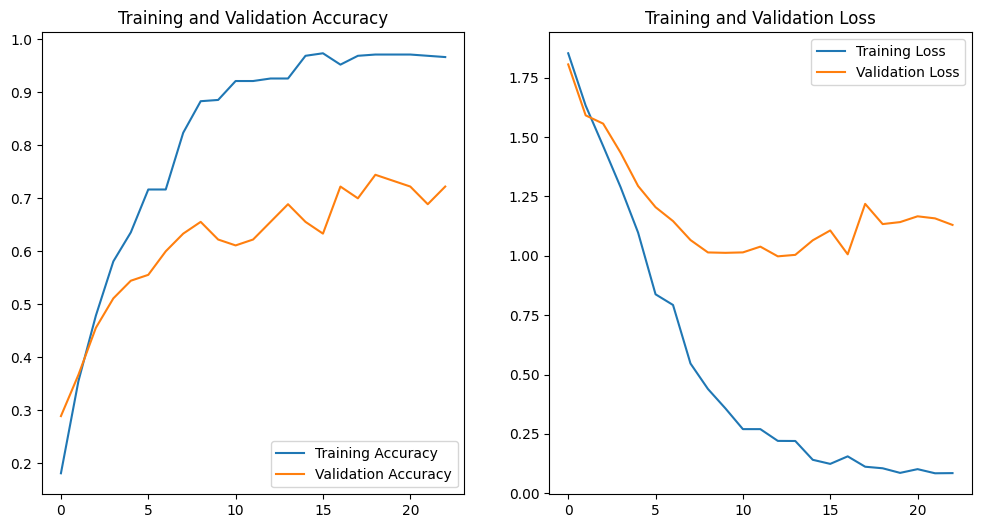

In [ ]:
import matplotlib.pyplot as plt

# extracting train and valid accuracy and loss from history
train_acc = history3.history['accuracy']
valid_acc = history3.history['val_accuracy']
train_loss = history3.history['loss']
valid_loss = history3.history['val_loss']

epochs_range = range(len(train_acc))  # no of epochs

plt.figure(figsize=(12, 6))

# Plotting Training and Valdation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, valid_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# plot Training and validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, valid_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

**Evaluating on Valid Set**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/inceptionv3_3_split2.keras")

loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy:.6f}")
print(f"Validation Loss: {loss:.6f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 870ms/step - accuracy: 0.6556 - loss: 0.9975
Validation Accuracy: 0.655556
Validation Loss: 0.997511


**Further training on Valid Set**

In [ ]:
from tensorflow.keras.models import load_model
import os

# loading and training the model
path = '/content/drive/My Drive/models/inceptionv3_3_split2.keras'
model = load_model(path)

# re-compile with low LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# training on validation dataset
model.fit(val_ds, epochs=5, verbose=1)

# saving the fine-tuned model
save_path = '/content/drive/My Drive/models/inceptionv3_3_split2_finetuned.keras'
model.save(save_path)
print(f'Model saved at: {save_path}')

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3000 - loss: 2.6626
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3222 - loss: 2.4613
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3556 - loss: 2.3876
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3889 - loss: 2.1392
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4556 - loss: 2.0358
Model saved at: /content/drive/My Drive/models/inceptionv3_3_split2_finetuned.keras


**Evaluating on Test Set**

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/My Drive/models/inceptionv3_3_split2_finetuned.keras")

loss, accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {accuracy:.6f}")
print(f"Test Loss: {loss:.6f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 43s 9s/step - accuracy: 0.6667 - loss: 0.9858
Test Accuracy: 0.666667
Test Loss: 0.985771


# Predicting on User Input

### Instructions
**Note**: Use only a single-face and single-die image for classification. The face should be visible and focused.

- **Upload Image**: Click the 'Upload' button to upload image from your device.

- **Predict**: After uploading, click the 'Predict Class' button to get the model's prediction and its confidence level.


### Interface

In [ ]:
import numpy as np
import io
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from PIL import Image

# UI Components
out = widgets.Output()
upload = widgets.FileUpload(accept='image/*', multiple=False)
predict_btn = widgets.Button(description="Predict Class", button_style='primary')

# load the final model
import tensorflow as tf
import os
import requests

# link to GitHub Release
url = "https://github.com/awahib480/Dice-Face-Recognition/releases/download/v1.0.0/inceptionv3_3_finetuned.keras"
output = "model.keras"

def download_model(url, filename):
    print(f"Downloading model from GitHub...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
    else:
        print(f"Failed to download. Status code: {response.status_code}")

try:
    # download only if it does not exist locally
    if not os.path.exists(output):
        download_model(url, output)

    # load the model
    model = tf.keras.models.load_model(output)
    status = "Model loaded successfully"

except Exception as e:
    status = f"Error loading model: {e}."

class_names = [1, 2, 3, 4, 5, 6]

def on_predict_clicked(b):
    with out:
        clear_output()
        if not upload.value:
            print("Please upload an image first!")
            return

        try:
            # Process upload
            file_info = list(upload.value.values())[0]
            img = Image.open(io.BytesIO(file_info['content'])).convert("RGB")

            # Display the uploaded image at a readable size
            print("Uploaded Image:")
            display(img.resize((100,100)))

            # Preprocess
            img_input = img.resize((96, 96))
            img_array = image.img_to_array(img_input) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Predict
            preds = model.predict(img_array, verbose=0)
            idx = np.argmax(preds)
            conf = np.max(preds) * 100

            print(f"\nResult: {class_names[idx]}")
            print(f"Confidence: {conf:.2f}%")
        except Exception as e:
            print(f"Prediction error: {e}")

predict_btn.on_click(on_predict_clicked)

# Layout
print(status)
ui = widgets.VBox([
    widgets.HTML("<h2>Dice Face Recognition</h2>"),
    widgets.Label("Upload an image of a die face to predict its class"),
    upload,
    predict_btn,
    out
])
display(ui)

Model loaded successfully


# Extension: KNN Algorithm

**Extracting features from a pre-trained CNN (MobileNetV2)**

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False  #freeze feature extractor

# pooling to convert feature maps into feature vectors
x = GlobalAveragePooling2D()(base_model.output)

# model
feature_extractor = Model(
    inputs = base_model.input,
    outputs = x
)

feature_extractor.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
import numpy as np

features = []
labels = []

for images, y in train_ds:
    f = feature_extractor.predict(images)

    features.append(f)
    labels.append(y)

features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


In [24]:
features.shape

(480, 1280)

## KNN Model 1

**Training KNN on extracted features**

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn_1 = KNeighborsClassifier(
    n_neighbors=3, # 3 closest neighbors to account for
    metric='euclidean', #straight line distance
    weights='distance' #closer neighbors get more importance
)

knn_1.fit(features, labels)

KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')

In [26]:
# saving the model
import joblib
import os

save_path = '/content/drive/My Drive/models'
joblib.dump(knn_1, os.path.join(save_path, 'knn_1.joblib'))
print(f"Model saved successfully at: {os.path.join(save_path, 'knn_model.joblib')}")

Model saved successfully at: /content/drive/My Drive/models/knn_model.joblib


**Predicting on Validation Data**

In [33]:
valid_features = []
valid_labels = []

for images, y in val_ds:
    f = feature_extractor.predict(images)

    valid_features.append(f)
    valid_labels.append(y)

valid_features = np.concatenate(valid_features, axis=0)
valid_labels = np.concatenate(valid_labels, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


In [29]:
import joblib
import os

# path to the saved model
load_path = '/content/drive/My Drive/models/knn_1.joblib'
knn = joblib.load(load_path)

y_pred = knn.predict(valid_features)

from sklearn.metrics import accuracy_score
acc = accuracy_score(valid_labels, y_pred)
print(f"Valid Accuracy: {acc:.6f}\n")

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(valid_labels, y_pred)
print("Confusion Matrix")
print(cm)

Valid Accuracy: 0.633333

Confusion Matrix
[[3 4 3 0 0 0]
 [0 9 1 0 0 0]
 [0 1 5 2 2 0]
 [1 0 1 6 1 1]
 [0 0 2 1 6 1]
 [0 0 0 1 0 9]]


## KNN Model 2

**Training KNN on extracted features**

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn_2 = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    weights='uniform' # all neighbors = equal priority
)

knn_2.fit(features, labels)

KNeighborsClassifier(metric='euclidean')

In [32]:
# saving the model
import joblib
import os

save_path = '/content/drive/My Drive/models'
joblib.dump(knn_2, os.path.join(save_path, 'knn_2.joblib'))
print(f"Model saved successfully at: {os.path.join(save_path, 'knn_2.joblib')}")

Model saved successfully at: /content/drive/My Drive/models/knn_2.joblib


**Extracting features and Evaluating on Valid Data**

In [34]:
valid_features = []
valid_labels = []

for images, y in val_ds:
    f = feature_extractor.predict(images)

    valid_features.append(f)
    valid_labels.append(y)

valid_features = np.concatenate(valid_features, axis=0)
valid_labels = np.concatenate(valid_labels, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


In [35]:
import joblib
import os

# path to the saved model
load_path = '/content/drive/My Drive/models/knn_2.joblib'
knn = joblib.load(load_path)

y_pred = knn.predict(valid_features)

from sklearn.metrics import accuracy_score
acc = accuracy_score(valid_labels, y_pred)
print(f"Valid Accuracy: {acc:.6f}\n")

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(valid_labels, y_pred)
print("Confusion Matrix")
print(cm)

Valid Accuracy: 0.600000

Confusion Matrix
[[4 3 1 1 0 1]
 [0 8 1 1 0 0]
 [1 1 4 2 2 0]
 [1 0 1 7 1 0]
 [0 1 1 1 7 0]
 [0 1 0 1 2 6]]


# Extension: SVM Algorithm





**Extracting features from a pre-trained CNN (MobileNetV2)**

In [7]:
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

feature_extractor = Model(
    inputs=base_model.input,
    outputs=x
)

feature_extractor.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
train_features = []
train_labels = []

for images, labels in train_ds:

    features = feature_extractor.predict(images)

    train_features.append(features)
    train_labels.append(labels)

train_features = np.concatenate(train_features, axis=0)
train_labels = np.concatenate(train_labels, axis=0)

print(train_features.shape)
print(train_labels.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
(480, 1280)
(480,)


**Training SVM on extracted features**

In [10]:
import joblib
import os
from sklearn.svm import SVC

# different C values
c_values = [0.1, 1, 10]
save_dir = '/content/drive/My Drive/models'

for c in c_values:
    print(f"Training SVM with C={c}...")

    # fit the model
    svm = SVC(
        kernel='rbf', # radial basis function
        C=c,  # regularization
        gamma='scale',  # assigns weights to training samples
        probability=True  # probabilities calculated
    )
    svm.fit(train_features, train_labels)

    # save the model
    filename = f'svm_C_{str(c)}.joblib'
    save_path = os.path.join(save_dir, filename)
    joblib.dump(svm, save_path)

    print(f"Model saved at: {save_path}\n")

Training SVM with C=0.1...
Model saved at: /content/drive/My Drive/models/svm_C_0.1.joblib

Training SVM with C=1...
Model saved at: /content/drive/My Drive/models/svm_C_1.joblib

Training SVM with C=10...
Model saved at: /content/drive/My Drive/models/svm_C_10.joblib



**Extracting Valid Data Features and Evaluating on Valid Data**

In [19]:
valid_features = []
valid_labels = []

for images, labels in val_ds:

    features = feature_extractor.predict(images)

    valid_features.append(features)
    valid_labels.append(labels)

valid_features = np.concatenate(valid_features, axis=0)
valid_labels = np.concatenate(valid_labels, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


In [20]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
valid_features = scaler.transform(valid_features)

In [21]:
import joblib
import os
from sklearn.metrics import accuracy_score, confusion_matrix

c_values = [0.1, 1, 10]
save_dir = '/content/drive/My Drive/models'

for c in c_values:
    # filename
    filename = f'svm_C_{str(c)}.joblib'
    load_path = os.path.join(save_dir, filename)

    if os.path.exists(load_path):
        svm_model = joblib.load(load_path)

        # predict
        y_pred = svm_model.predict(valid_features)
        acc = accuracy_score(valid_labels, y_pred)

        print(f"----- SVM for C={c} -----")
        print(f"Valid Accuracy: {acc:.6f}")

        cm = confusion_matrix(valid_labels, y_pred)
        print("Confusion Matrix:")
        print(cm)
        print("\n")
    else:
        print(f"Model not found: {load_path}")

----- SVM for C=0.1 -----
Valid Accuracy: 0.433333
Confusion Matrix:
[[2 5 3 0 0 0]
 [1 6 2 0 1 0]
 [1 2 6 0 1 0]
 [2 1 1 1 5 0]
 [0 0 3 0 6 1]
 [0 1 0 0 4 5]]


----- SVM for C=1 -----
Valid Accuracy: 0.600000
Confusion Matrix:
[[5 3 2 0 0 0]
 [1 6 2 0 1 0]
 [2 2 5 1 0 0]
 [1 1 1 5 2 0]
 [0 0 2 0 8 0]
 [1 1 0 0 1 7]]


----- SVM for C=10 -----
Valid Accuracy: 0.650000
Confusion Matrix:
[[5 2 3 0 0 0]
 [1 8 1 0 0 0]
 [2 2 6 0 0 0]
 [1 1 1 4 3 0]
 [0 0 1 0 9 0]
 [1 0 1 0 1 7]]


